### Layout-Aware RAG using LandingAI ADE + Chroma + LangChain

This notebook demonstrates a document RAG pipeline using:

- LandingAI ADE for document parsing
- ChromaDB for vector storage
- OpenAI embeddings + LLM
- Layout-aware evidence visualization

### Imports

In [11]:
import os
import re
import json
import chromadb
import pymupdf
import openai
import random

from dotenv import load_dotenv
from PIL import Image as PILImage, ImageDraw
from IPython.display import display

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_chroma import Chroma
from collections import Counter

from pathlib import Path
from landingai_ade import LandingAIADE

### Load environment variables

In [2]:
load_dotenv()

OPENAI_API_KEY=os.getenv("OPENAI_API_KEY")
ADE_API_KEY=os.getenv("VISION_AGENT_API_KEY")

### Setup Langsmith Tracking and API Key

In [3]:
os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["LANGSMITH_API_KEY"]=os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"]="RAG_WITH_ADE"

### Initialise LLM

In [4]:
llm = ChatOpenAI(model="gpt-4.1-nano",
                    api_key=OPENAI_API_KEY,
                    temperature=0.5,
                    max_tokens=512 )

### Parse Document using ADE

In [ ]:
document_path="sample_data/PID5117895.pdf"
output_dir="ade_outputs"
os.makedirs(output_dir, exist_ok=True)

markdown_path=os.path.join(output_dir,"output.md")


client = LandingAIADE(
  apikey=ADE_API_KEY,
)

parse_response = client.parse(
  document=Path(document_path),
  model="dpt-2",
  save_to=output_dir
)


# Save Markdown output
with open(markdown_path, "w", encoding="utf-8") as f:
    f.write(parse_response.markdown)

In [6]:
print(f"job_id: {parse_response.metadata.job_id}")
print(f"Filename: {parse_response.metadata.filename}")
print(f"Total time (ms): {parse_response.metadata.duration_ms}")
print(f"Total pages: {len(parse_response.splits)}")
print(f"Total markdown characters: {len(parse_response.markdown)}")
print(f"Total chunks: {len(parse_response.chunks)}")

job_id: 09ffaaf83d204c66a7cf10bb6d70cda9
Filename: PID5117895.pdf
Total time (ms): 19010
Total pages: 1
Total markdown characters: 30291
Total chunks: 43


### Get Chunk type counts

In [10]:
types = [chunk.type for chunk in parse_response.chunks]
counts = Counter(types)
print(counts)

Counter({'text': 36, 'table': 5, 'figure': 2})


### Visualise Layout aware chunks

Page 0


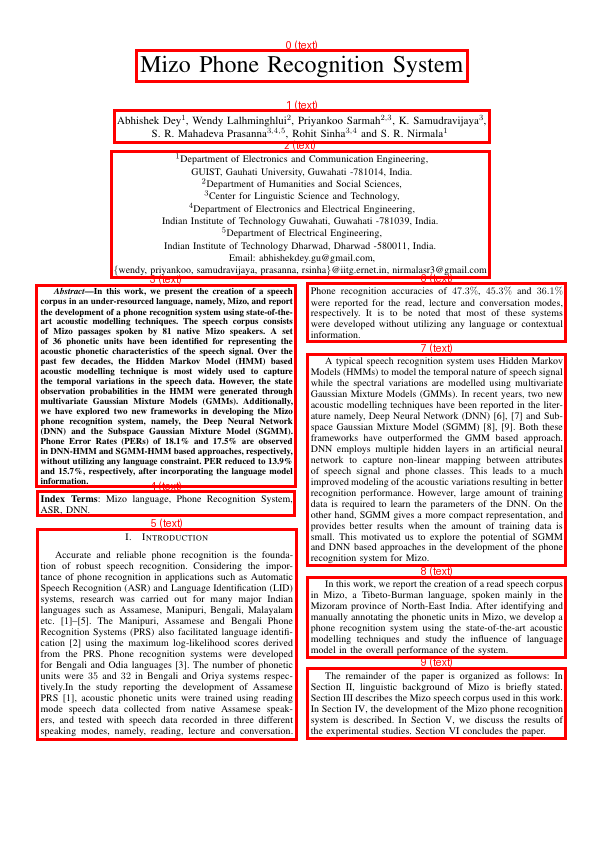

Page 1


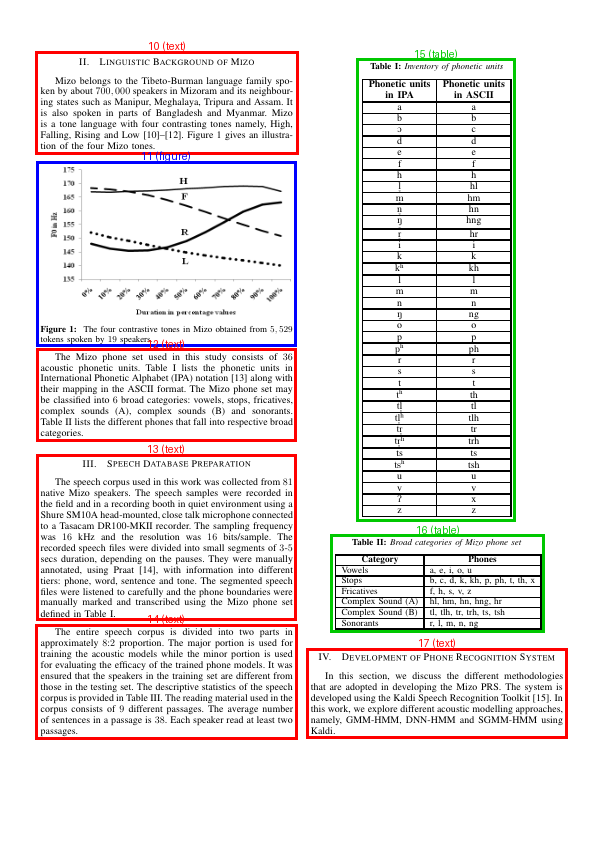

Page 2


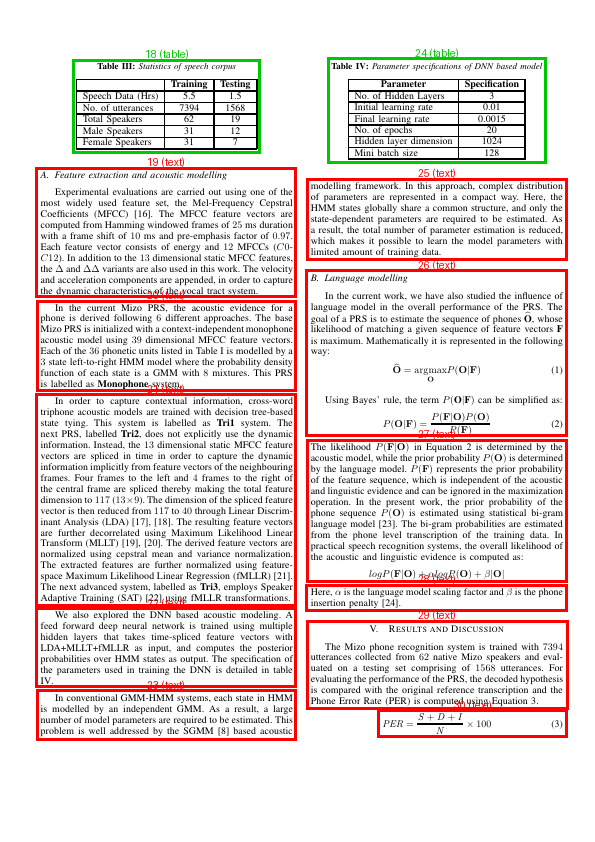

Page 3


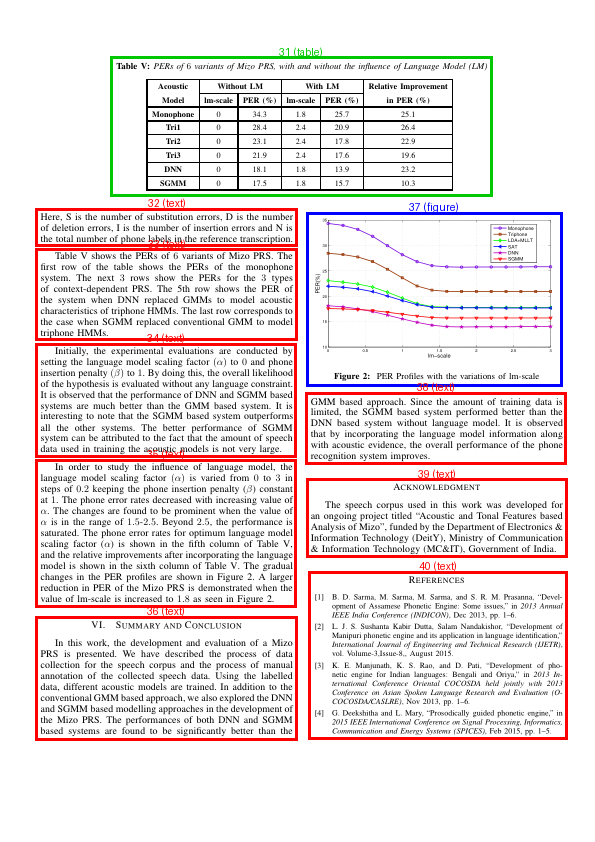

Page 4


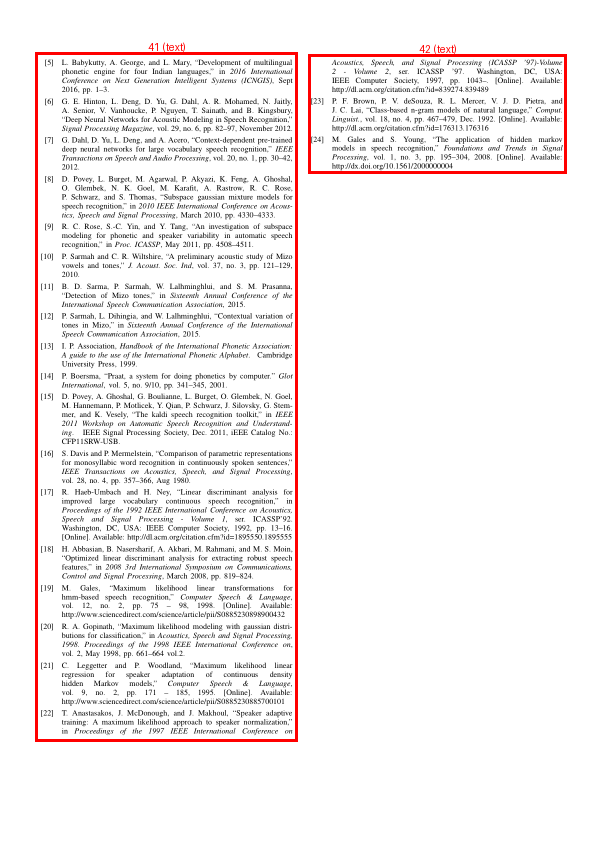

In [13]:
random.seed(42)

pdf = pymupdf.open(document_path)

types = sorted(set(chunk.type for chunk in parse_response.chunks))

'''
color_map = {
    t: tuple(random.randint(0,255) for _ in range(3))
    for t in types
}
'''
color_map = {
    "logo": (255,165,0),       # Orange
    "text": (255,0,0),         # Red
    "table": (0,200,0),        # Green
    "figure": (0,0,255),       # Blue
    "marginalia": (255,0,255), # Magenta
    "attestation": (0,255,255) # Cyan
}

padding = 1
pages = []

for page_index in range(len(pdf)):

    page = pdf.load_page(page_index)
    pix = page.get_pixmap()

    img = PILImage.frombytes("RGB", [pix.width, pix.height], pix.samples)
    draw = ImageDraw.Draw(img)

    for idx, chunk in enumerate(parse_response.chunks):

        if chunk.grounding.page != page_index:
            continue

        box = chunk.grounding.box

        left = box.left * img.width
        right = box.right * img.width
        top = box.top * img.height
        bottom = box.bottom * img.height

        color = color_map[chunk.type]

        draw.rectangle([left, top, right, bottom], outline=color, width=3)

        label = f"{idx} ({chunk.type})"

        center_x = (left + right) / 2

        bbox = draw.textbbox((0,0), label)
        text_w = bbox[2] - bbox[0]
        text_h = bbox[3] - bbox[1]

        text_x = center_x - text_w / 2
        text_y = top - text_h - padding

        draw.text((text_x, text_y), label, fill=color)

    # show in notebook
    print(f"Page {page_index}")
    display(img)

    # store for PDF writing
    pages.append(img)


### Write the annotated output

In [14]:
# write annotated pdf
output_pdf = os.path.join(output_dir,"annotated_document.pdf")

pages[0].save(
    output_pdf,
    save_all=True,
    append_images=pages[1:]
)

### Load ADE Chunks

In [15]:
ADE_JSON_PATH = os.path.join(output_dir,"PID5117895_parse_output.json")

with open(ADE_JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

chunks = data["chunks"]

print("Loaded chunks:", len(chunks))

Loaded chunks: 43


### Initialise ChromaDB

In [16]:
CHROMA_DB_PATH = "./ade_chroma_db"
chroma_client = chromadb.PersistentClient(path=CHROMA_DB_PATH)
collection = chroma_client.get_or_create_collection("ade_rag")

### Insert Chunks into ChromaDB

In [18]:
EMBEDDING_MODEL = "text-embedding-3-small"

existing = collection.get()
existing_ids = set(existing.get("ids", []))

added = 0

for chunk in chunks:

    chunk_id = chunk["id"]

    if chunk_id in existing_ids:
        continue

    text = re.sub(r"<a.*?>.*?</a>", "", chunk["markdown"]).strip()

    emb = openai.embeddings.create(
        input=text,
        model=EMBEDDING_MODEL
    ).data[0].embedding

    meta = {
        "page": chunk["grounding"]["page"],
        "chunk_type": chunk["type"],
        "bbox_left": chunk["grounding"]["box"]["left"],
        "bbox_top": chunk["grounding"]["box"]["top"],
        "bbox_right": chunk["grounding"]["box"]["right"],
        "bbox_bottom": chunk["grounding"]["box"]["bottom"],
    }

    collection.add(
        documents=[text],
        ids=[chunk_id],
        embeddings=[emb],
        metadatas=[meta],
    )

    added += 1

print("Added chunks:", added)

Added chunks: 43


### Retriever

In [19]:
def retrieve(question, top_k=3):

    emb = openai.embeddings.create(
        input=question,
        model=EMBEDDING_MODEL
    ).data[0].embedding

    results = collection.query(
        query_embeddings=[emb],
        n_results=top_k,
        include=["documents", "metadatas"]
    )

    docs = []

    for text, meta in zip(results["documents"][0], results["metadatas"][0]):

        docs.append(
            Document(
                page_content=text,
                metadata=meta
            )
        )

    return docs

### Prompt

In [20]:
prompt = ChatPromptTemplate.from_template("""
You are a helpful assistant.

Answer the question using ONLY the provided context.

Rules:
- If the answer comes from a table, reproduce it clearly.
- Use bullet points or tables where appropriate.
- If the context does not contain the answer, say "I don't know."

Context:
{context}

Question:
{question}
""")

### Format Context

In [21]:
def format_docs(docs):

    return "\n\n".join(d.page_content for d in docs)

### Visual Evidence Helper

In [22]:
def show_page_with_bbox(pdf_path, page_num, bbox):

    doc = pymupdf.open(pdf_path)
    page = doc.load_page(page_num)

    pix = page.get_pixmap()

    img = PILImage.frombytes("RGB", [pix.width, pix.height], pix.samples)

    draw = ImageDraw.Draw(img)

    x0 = int(bbox[0] * img.width)
    y0 = int(bbox[1] * img.height)
    x1 = int(bbox[2] * img.width)
    y1 = int(bbox[3] * img.height)

    draw.rectangle([x0, y0, x1, y1], outline="red", width=4)

    display(img)

### RAG

In [25]:
def ask(question):

    docs = retrieve(question)

    context = format_docs(docs)

    chain = prompt | llm | StrOutputParser()

    answer = chain.invoke({
        "context": context,
        "question": question
    })

    print("\nAnswer:\n")
    print(answer)

    print("\nEvidence:\n")

    best = docs[0]

    meta = best.metadata

    bbox = [
        meta["bbox_left"],
        meta["bbox_top"],
        meta["bbox_right"],
        meta["bbox_bottom"]
    ]

    show_page_with_bbox(
        document_path,
        meta["page"],
        bbox
    )

## QNA


Answer:

The Broad Categories of Mizo phone set and examples for each category are:

- Vowels: a, e, i, o, u
- Stops: b, c, d, k, kh, p, ph, t, th, x
- Fricatives: f, h, s, v, z
- Complex Sound (A): hl, hm, hn, hng, hr
- Complex Sound (B): tl, tlh, tr, trh, ts, tsh
- Sonorants: r, l, m, n, ng

Evidence:



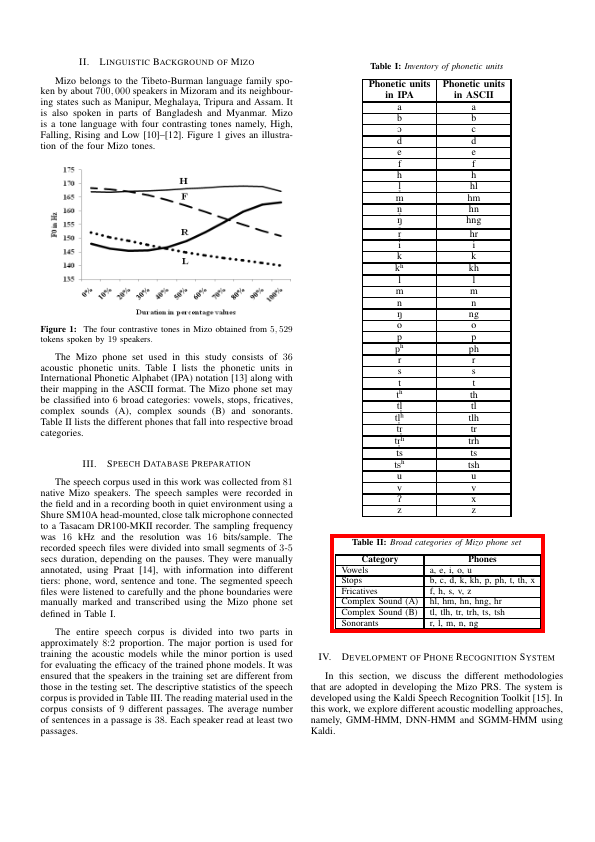

In [26]:
ask("What were the Broad Categories of Mizo phone set? Give examples for each category")


Answer:

The statistics of the speech corpus used in this work are as follows:

| Category                | Training             | Testing             |
|-------------------------|----------------------|---------------------|
| Speech Data (Hrs)       | 5.5                  | 1.5                 |
| No. of utterances      | 7394                 | 1568                |
| Total Speakers          | 62                   | 19                  |
| Male Speakers           | 31                   | 12                  |
| Female Speakers         | 31                   | 7                   |

Evidence:



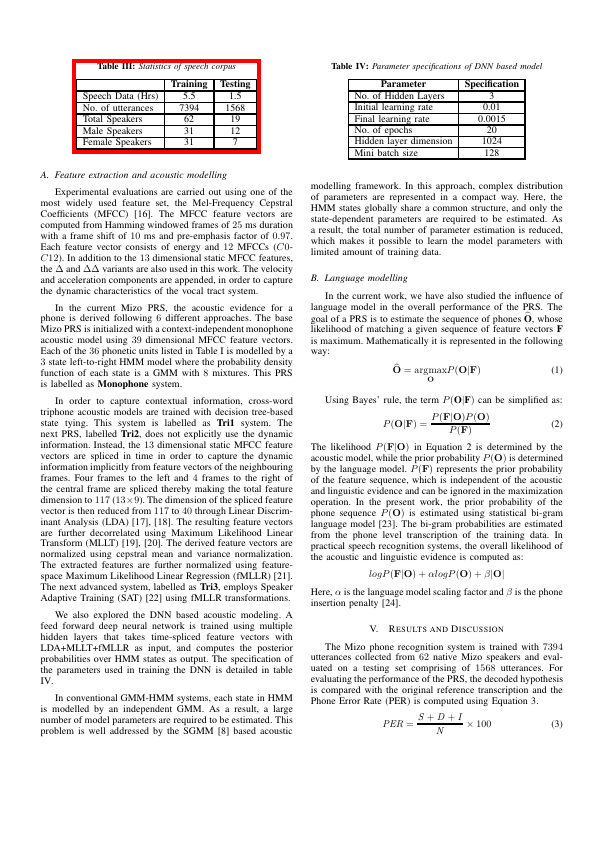

In [27]:
ask("Give me the statistics of the speech corpus used in this work")


Answer:

The model parameters are:

- No. of Hidden Layers: 3
- Initial learning rate: 0.01
- Final learning rate: 0.0015
- No. of epochs: 20
- Hidden layer dimension: 1024
- Mini batch size: 128

Evidence:



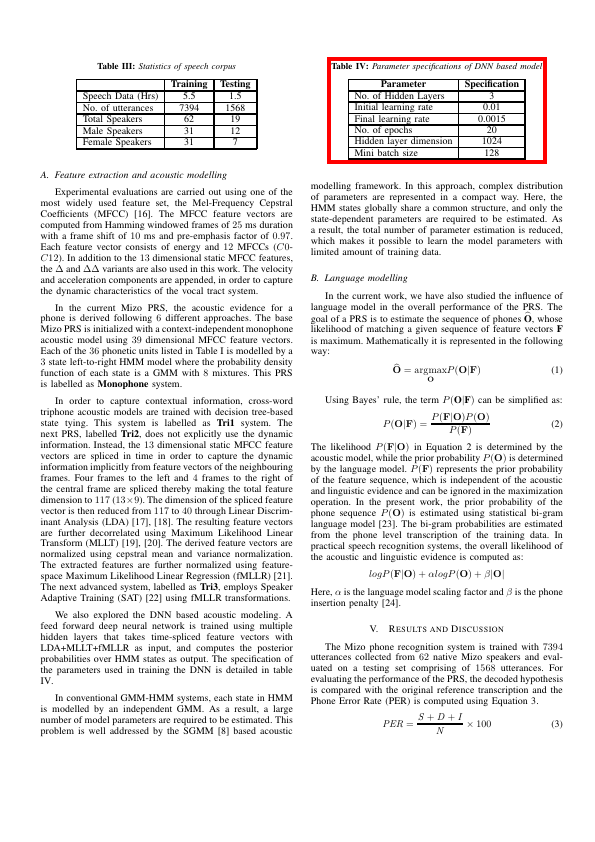

In [28]:
ask("What are the model parameters?")